Force Control of 1200N

In [ ]:
!pip install control optuna matplotlib numpy scipy plotly kaleido

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from control import tf, feedback, step_response, forced_response, margin
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_slice,
    plot_contour
)

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Mass-spring-damper parameters
m = 1.0   # mass (kg)
c = 10.0  # damping coefficient (N*s/m)
k = 20.0  # spring constant (N/m)

# Plant: G(s) = 1 / (ms^2 + cs + k)
G = tf([1], [m, c, k])
print("Plant transfer function:")
print(G)

Plant transfer function:
<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

         1
  ---------------
  s^2 + 10 s + 20


In [ ]:
def build_filtered_pid(Kp, Ki, Kd, N):
    """
    Builds the filtered PID transfer function:
    C(s) = Kp + Ki/s + Kd*s/(s/N + 1)
    Combined form: C(s) = [(Kp + Kd*N)s^2 + (Ki + Kp*N)s + Ki*N] / [s(s + N)]
    """
    num = [Kp + Kd*N, Ki + Kp*N, Ki*N]
    den = [1, N, 0]
    return tf(num, den)


def evaluate_pid_full(Kp, Ki, Kd, N, plant, t_sim=5.0, n_points=2000, setpoint=1.0):
    """
    Simulates closed-loop with filtered PID and computes all metrics.

    Returns dict with:
      - Transient: settling_time, overshoot, peak, rise_time
      - Integral: iae, ise
      - Control effort: peak_force, total_effort
      - Frequency: gain_margin_db, phase_margin_deg
      - Stability: is_stable
      - Time series: t, y, u (for plotting)
    """
    try:
        C = build_filtered_pid(Kp, Ki, Kd, N)

        # Closed-loop transfer functions
        L = C * plant                    # Loop gain
        T = feedback(L, 1)               # Closed-loop (reference to output)
        CS = feedback(C, plant)          # Reference to control signal: U/R = C/(1+CL)

        t = np.linspace(0, t_sim, n_points)

        # Step response: output y(t)
        t, y = step_response(T, t)

        # Step response: control signal u(t)
        t, u = step_response(CS, t)

        # Scale by setpoint
        y = y * setpoint
        u = u * setpoint

        # Sanity check for instability
        if (np.any(np.isnan(y)) or np.any(np.isinf(y))
            or np.max(np.abs(y)) > 100):
            return {'is_stable': False}

        error = setpoint - y

        # --- Transient metrics ---
        peak = np.max(y)
        overshoot = max(0.0, (peak - setpoint) / setpoint * 100)

        # Settling time (2% criterion)
        settling_band = 0.02 * setpoint
        outside_band = np.where(np.abs(error) > settling_band)[0]
        settling_time = t[outside_band[-1]] if len(outside_band) > 0 else 0.0

        # Rise time (10% to 90%)
        try:
            t_10 = t[np.where(y >= 0.1 * setpoint)[0][0]]
            t_90 = t[np.where(y >= 0.9 * setpoint)[0][0]]
            rise_time = t_90 - t_10
        except IndexError:
            rise_time = np.nan

        # --- Integral metrics ---
        iae = np.trapz(np.abs(error), t)
        ise = np.trapz(error**2, t)

        # --- Control effort metrics ---
        peak_force = np.max(np.abs(u))
        total_effort = np.trapz(np.abs(u), t)

        # --- Steady-state error ---
        sse = abs(error[-1])

        # --- Frequency-domain metrics ---
        try:
            gm, pm, wcg, wcp = margin(L)
            gain_margin_db = 20 * np.log10(gm) if gm > 0 and np.isfinite(gm) else np.inf
            phase_margin_deg = pm
        except Exception:
            gain_margin_db = np.nan
            phase_margin_deg = np.nan

        return {
            'is_stable': True,
            'settling_time': settling_time,
            'overshoot': overshoot,
            'peak': peak,
            'rise_time': rise_time,
            'iae': iae,
            'ise': ise,
            'peak_force': peak_force,
            'total_effort': total_effort,
            'sse': sse,
            'gain_margin_db': gain_margin_db,
            'phase_margin_deg': phase_margin_deg,
            't': t,
            'y': y,
            'u': u
        }
    except Exception as e:
        return {'is_stable': False, 'error': str(e)}

In [ ]:
# Engineering specifications
MAX_OVERSHOOT = 5.0      # %
MAX_SSE = 0.01           # absolute
MAX_PEAK_FORCE = 1200.0  # N — matched to MATLAB's natural peak


def constraints_func(trial):
    """
    Returns the constraint violations for Optuna's TPE sampler.
    Each value: positive means VIOLATED, <= 0 means satisfied.
    """
    return trial.user_attrs.get("constraints", (1.0, 1.0))


def objective(trial):
    """
    Constrained optimization:
      minimize: settling_time
      subject to:
        overshoot <= 5%
        sse <= 0.01
    """
    Kp = trial.suggest_float('Kp', 0.1, 300)
    Ki = trial.suggest_float('Ki', 0.0, 300)
    Kd = trial.suggest_float('Kd', 0.0, 50)
    N  = trial.suggest_float('N', 1, 500)

    result = evaluate_pid_full(Kp, Ki, Kd, N, G)

    if not result.get('is_stable', False):
        # Mark as heavily violated
        trial.set_user_attr("constraints", (1e3, 1e3))
        return 1e6

    # Compute constraint violations (positive = violated)
    c1 = result['overshoot'] - MAX_OVERSHOOT   # overshoot <= 5%
    c2 = result['sse'] - MAX_SSE               # sse <= 0.01
    c3 = result['peak_force'] - MAX_PEAK_FORCE


    trial.set_user_attr("constraints", (c1, c2,c3))

    # Store full metrics for later analysis
    trial.set_user_attr("metrics", {
        'settling_time': result['settling_time'],
        'overshoot': result['overshoot'],
        'peak_force': result['peak_force'],
        'total_effort': result['total_effort'],
        'iae': result['iae'],
        'ise': result['ise'],
        'gain_margin_db': result['gain_margin_db'],
        'phase_margin_deg': result['phase_margin_deg'],
    })

    # Objective: settling time only (constraints handled separately)
    return result['settling_time']


# Build the sampler with constraint support
sampler = optuna.samplers.TPESampler(
    seed=42,
    constraints_func=constraints_func,
    n_startup_trials=20
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='constrained_pid_bo'
)

print("Running constrained Bayesian Optimization...")
print(f"Constraints: Overshoot <= {MAX_OVERSHOOT}%, SSE <= {MAX_SSE}")
print("-" * 60)

study.optimize(objective, n_trials=200, show_progress_bar=True)

In [ ]:
def get_best_feasible_trial(study):
    """Returns the feasible trial with the lowest objective value."""
    feasible_trials = []
    for trial in study.trials:
        if trial.state != optuna.trial.TrialState.COMPLETE:
            continue
        constraints = trial.user_attrs.get("constraints", (1e3, 1e3))
        if all(c <= 0 for c in constraints):
            feasible_trials.append(trial)

    if not feasible_trials:
        return None
    return min(feasible_trials, key=lambda t: t.value)


best = get_best_feasible_trial(study)

if best is None:
    print("⚠️ No feasible solution found! Consider relaxing constraints.")
else:
    print("\n" + "="*60)
    print("BEST FEASIBLE SOLUTION (BO-tuned)")
    print("="*60)
    print(f"\nGains:")
    print(f"  Kp = {best.params['Kp']:.4f}")
    print(f"  Ki = {best.params['Ki']:.4f}")
    print(f"  Kd = {best.params['Kd']:.4f}")
    print(f"  N  = {best.params['N']:.4f}")

    m_dict = best.user_attrs["metrics"]
    print(f"\nPerformance Metrics:")
    print(f"  Settling time:     {m_dict['settling_time']:.4f} s")
    print(f"  Overshoot:         {m_dict['overshoot']:.4f} %")
    print(f"  Peak force:        {m_dict['peak_force']:.4f}")
    print(f"  Total effort:      {m_dict['total_effort']:.4f}")
    print(f"  IAE:               {m_dict['iae']:.4f}")
    print(f"  ISE:               {m_dict['ise']:.4f}")
    print(f"  Gain margin:       {m_dict['gain_margin_db']:.2f} dB")
    print(f"  Phase margin:      {m_dict['phase_margin_deg']:.2f} deg")

    print(f"\nTotal feasible trials: "
          f"{sum(1 for t in study.trials if all(c <= 0 for c in t.user_attrs.get('constraints', (1,1))))}"
          f" / {len(study.trials)}")


BEST FEASIBLE SOLUTION (BO-tuned)

Gains:
  Kp = 204.2185
  Ki = 299.9179
  Kd = 14.9299
  N  = 66.6323

Performance Metrics:
  Settling time:     0.1251 s
  Overshoot:         1.1638 %
  Peak force:        1199.0330
  Total effort:      117.9419
  IAE:               0.0681
  ISE:               0.0345
  Gain margin:       inf dB
  Phase margin:      71.15 deg

Total feasible trials: 95 / 200


/tmp/ipykernel_686/2209227432.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  iae = np.trapz(np.abs(error), t)
/tmp/ipykernel_686/2209227432.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ise = np.trapz(error**2, t)
/tmp/ipykernel_686/2209227432.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_effort = np.trapz(np.abs(u), t)


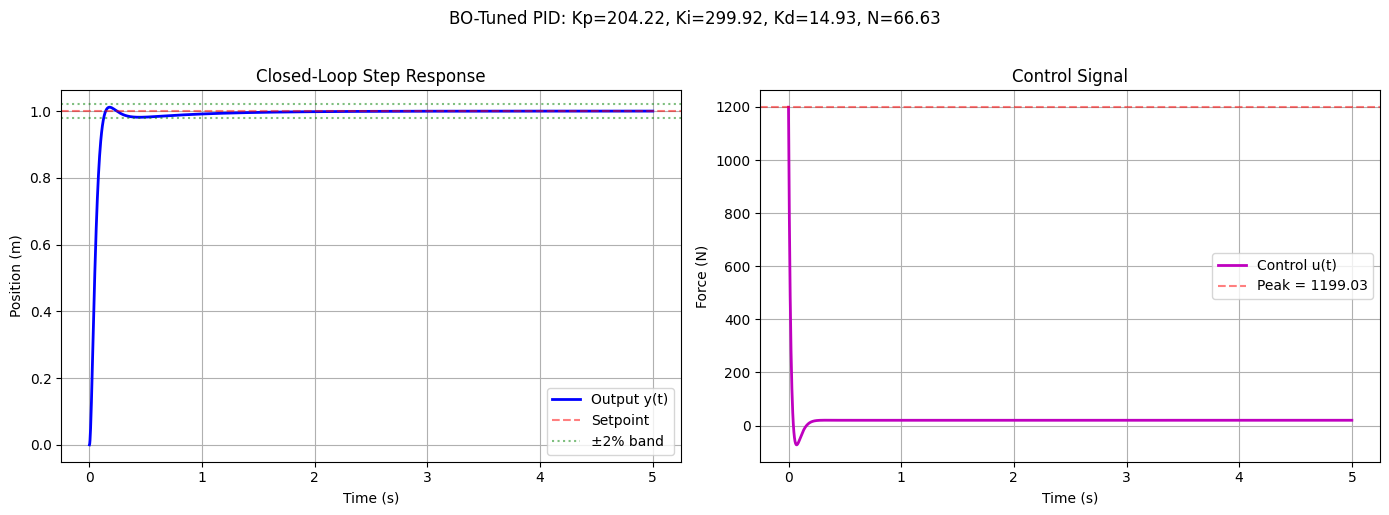

In [ ]:
best_params = best.params
result = evaluate_pid_full(
    best_params['Kp'],
    best_params['Ki'],
    best_params['Kd'],
    best_params['N'],
    G
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Output response
axes[0].plot(result['t'], result['y'], 'b-', linewidth=2, label='Output y(t)')
axes[0].axhline(y=1, color='r', linestyle='--', alpha=0.5, label='Setpoint')
axes[0].axhline(y=1.02, color='g', linestyle=':', alpha=0.5, label='±2% band')
axes[0].axhline(y=0.98, color='g', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (m)')
axes[0].set_title('Closed-Loop Step Response')
axes[0].legend()
axes[0].grid(True)

# Control signal
axes[1].plot(result['t'], result['u'], 'm-', linewidth=2, label='Control u(t)')
axes[1].axhline(y=result['peak_force'], color='r', linestyle='--', alpha=0.5,
                label=f'Peak = {result["peak_force"]:.2f}')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Force (N)')
axes[1].set_title('Control Signal')
axes[1].legend()
axes[1].grid(True)

plt.suptitle(f'BO-Tuned PID: Kp={best_params["Kp"]:.2f}, '
             f'Ki={best_params["Ki"]:.2f}, Kd={best_params["Kd"]:.2f}, '
             f'N={best_params["N"]:.2f}', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Canonical configuration
MAX_OVERSHOOT = 5.0       # %
MAX_SSE = 0.01            # absolute
MAX_PEAK_FORCE = 1200.0   # N

def constraints_func(trial):
    return trial.user_attrs.get("constraints", (1.0, 1.0, 1.0))

def objective_canonical(trial):
    Kp = trial.suggest_float('Kp', 0.1, 300)
    Ki = trial.suggest_float('Ki', 0.0, 300)
    Kd = trial.suggest_float('Kd', 0.0, 50)
    N  = trial.suggest_float('N', 1, 500)

    result = evaluate_pid_full(Kp, Ki, Kd, N, G)

    if not result.get('is_stable', False):
        trial.set_user_attr("constraints", (1e3, 1e3, 1e3))
        return 1e6

    c1 = result['overshoot']  - MAX_OVERSHOOT
    c2 = result['sse']        - MAX_SSE
    c3 = result['peak_force'] - MAX_PEAK_FORCE

    trial.set_user_attr("constraints", (c1, c2, c3))
    trial.set_user_attr("metrics", {
        'settling_time': result['settling_time'],
        'overshoot': result['overshoot'],
        'peak_force': result['peak_force'],
        'total_effort': result['total_effort'],
        'iae': result['iae'],
        'ise': result['ise'],
        'gain_margin_db': result['gain_margin_db'],
        'phase_margin_deg': result['phase_margin_deg'],
    })

    return result['settling_time']


sampler = optuna.samplers.TPESampler(
    seed=42,
    constraints_func=constraints_func,
    n_startup_trials=20
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='canonical_pid_bo_1200N'
)

print(f"Canonical BO run: constraints = "
      f"OS≤{MAX_OVERSHOOT}%, SSE≤{MAX_SSE}, |u|≤{MAX_PEAK_FORCE}N")
print("-" * 60)
study.optimize(objective_canonical, n_trials=300, show_progress_bar=True)

best = get_best_feasible_trial(study)
print(f"\nBest feasible settling time: {best.value:.4f} s")
print(f"Best gains: Kp={best.params['Kp']:.3f}, Ki={best.params['Ki']:.3f}, "
      f"Kd={best.params['Kd']:.3f}, N={best.params['N']:.3f}")

Canonical BO run: constraints = OS≤5.0%, SSE≤0.01, |u|≤1200.0N
------------------------------------------------------------


/tmp/ipykernel_686/1364644298.py:40: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(


  0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_686/2209227432.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  iae = np.trapz(np.abs(error), t)
/tmp/ipykernel_686/2209227432.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ise = np.trapz(error**2, t)
/tmp/ipykernel_686/2209227432.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_effort = np.trapz(np.abs(u), t)



Best feasible settling time: 0.1251 s
Best gains: Kp=204.218, Ki=299.918, Kd=14.930, N=66.632


Confirm Canonical Configuration and Re-run if Needed

In [ ]:
# Canonical configuration
MAX_OVERSHOOT = 5.0       # %
MAX_SSE = 0.01            # absolute
MAX_PEAK_FORCE = 1200.0   # N

def constraints_func(trial):
    return trial.user_attrs.get("constraints", (1.0, 1.0, 1.0))

def objective_canonical(trial):
    Kp = trial.suggest_float('Kp', 0.1, 300)
    Ki = trial.suggest_float('Ki', 0.0, 300)
    Kd = trial.suggest_float('Kd', 0.0, 50)
    N  = trial.suggest_float('N', 1, 500)

    result = evaluate_pid_full(Kp, Ki, Kd, N, G)

    if not result.get('is_stable', False):
        trial.set_user_attr("constraints", (1e3, 1e3, 1e3))
        return 1e6

    c1 = result['overshoot']  - MAX_OVERSHOOT
    c2 = result['sse']        - MAX_SSE
    c3 = result['peak_force'] - MAX_PEAK_FORCE

    trial.set_user_attr("constraints", (c1, c2, c3))
    trial.set_user_attr("metrics", {
        'settling_time': result['settling_time'],
        'overshoot': result['overshoot'],
        'peak_force': result['peak_force'],
        'total_effort': result['total_effort'],
        'iae': result['iae'],
        'ise': result['ise'],
        'gain_margin_db': result['gain_margin_db'],
        'phase_margin_deg': result['phase_margin_deg'],
    })

    return result['settling_time']


sampler = optuna.samplers.TPESampler(
    seed=42,
    constraints_func=constraints_func,
    n_startup_trials=20
)

study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='canonical_pid_bo_1200N'
)

print(f"Canonical BO run: constraints = "
      f"OS≤{MAX_OVERSHOOT}%, SSE≤{MAX_SSE}, |u|≤{MAX_PEAK_FORCE}N")
print("-" * 60)
study.optimize(objective_canonical, n_trials=300, show_progress_bar=True)

best = get_best_feasible_trial(study)
print(f"\nBest feasible settling time: {best.value:.4f} s")
print(f"Best gains: Kp={best.params['Kp']:.3f}, Ki={best.params['Ki']:.3f}, "
      f"Kd={best.params['Kd']:.3f}, N={best.params['N']:.3f}")

Canonical BO run: constraints = OS≤5.0%, SSE≤0.01, |u|≤1200.0N
------------------------------------------------------------


/tmp/ipykernel_686/1364644298.py:40: ExperimentalWarning: Argument ``constraints_func`` is an experimental feature. The interface can change in the future.
  sampler = optuna.samplers.TPESampler(


  0%|          | 0/300 [00:00<?, ?it/s]

/tmp/ipykernel_686/2209227432.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  iae = np.trapz(np.abs(error), t)
/tmp/ipykernel_686/2209227432.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ise = np.trapz(error**2, t)
/tmp/ipykernel_686/2209227432.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_effort = np.trapz(np.abs(u), t)



Best feasible settling time: 0.1251 s
Best gains: Kp=204.218, Ki=299.918, Kd=14.930, N=66.632


Parameter Importance (fANOVA)

PARAMETER IMPORTANCE (fANOVA)

This quantifies how much each parameter contributes to
variance in the settling time across the search space.

Parameter  Importance
       Ki    0.800577
       Kp    0.177479
       Kd    0.019082
        N    0.002862


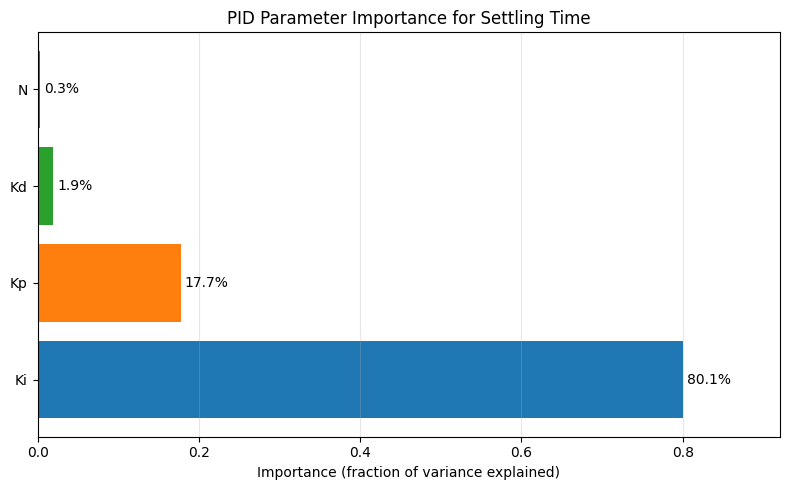

In [ ]:
import pandas as pd

print("="*60)
print("PARAMETER IMPORTANCE (fANOVA)")
print("="*60)
print("\nThis quantifies how much each parameter contributes to")
print("variance in the settling time across the search space.\n")

# Compute importance for the primary objective (settling time)
importance = optuna.importance.get_param_importances(
    study,
    evaluator=optuna.importance.FanovaImportanceEvaluator(seed=42)
)

importance_df = pd.DataFrame(
    list(importance.items()),
    columns=['Parameter', 'Importance']
)
print(importance_df.to_string(index=False))

# Visualize as bar chart
fig, ax = plt.subplots(figsize=(8, 5))
params = list(importance.keys())
values = list(importance.values())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax.barh(params, values, color=colors[:len(params)])
ax.set_xlabel('Importance (fraction of variance explained)')
ax.set_title('PID Parameter Importance for Settling Time')
ax.grid(True, axis='x', alpha=0.3)

# Annotate bars with percentages
for bar, val in zip(bars, values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)

ax.set_xlim(0, max(values) * 1.15)
plt.tight_layout()
plt.show()

Slice Plots — How Each Parameter Affects Settling Time

SLICE PLOTS: Settling Time vs. Each Parameter

Each point is one BO trial. Blue = feasible, red = infeasible.
Look for: monotonic trends, optima, flat regions, sensitivity.

Total trials: 300, Feasible: 164


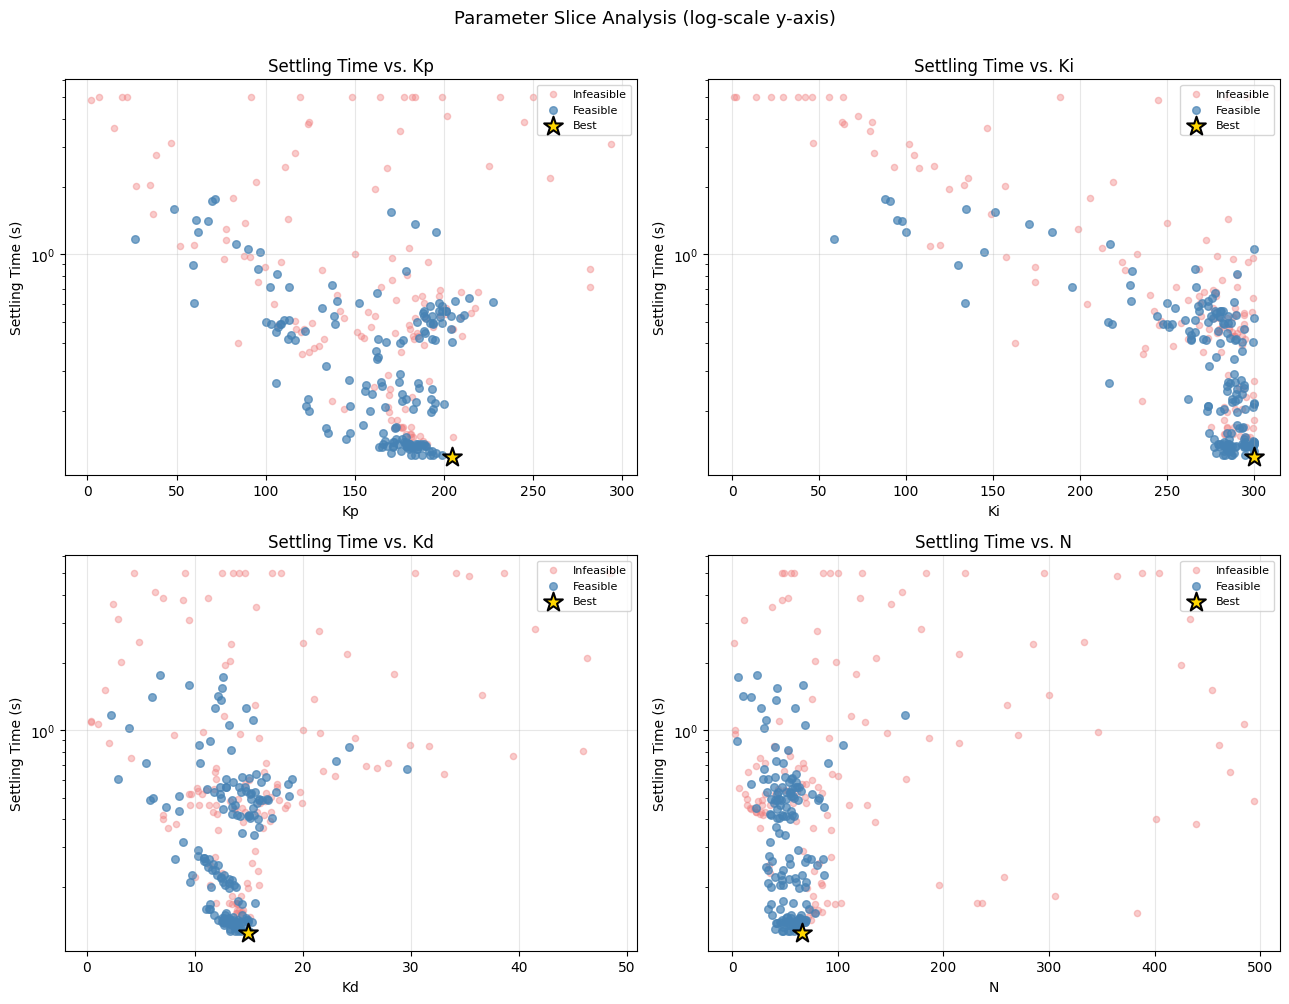

In [ ]:
print("="*60)
print("SLICE PLOTS: Settling Time vs. Each Parameter")
print("="*60)
print("\nEach point is one BO trial. Blue = feasible, red = infeasible.")
print("Look for: monotonic trends, optima, flat regions, sensitivity.\n")

# Extract trial data
trial_data = []
for t in study.trials:
    if t.state != optuna.trial.TrialState.COMPLETE:
        continue
    if 'metrics' not in t.user_attrs:
        continue
    constraints = t.user_attrs.get("constraints", (1, 1, 1))
    feasible = all(c <= 0 for c in constraints)
    trial_data.append({
        'Kp': t.params['Kp'],
        'Ki': t.params['Ki'],
        'Kd': t.params['Kd'],
        'N':  t.params['N'],
        'settling_time': t.user_attrs['metrics']['settling_time'],
        'feasible': feasible
    })

df = pd.DataFrame(trial_data)
print(f"Total trials: {len(df)}, Feasible: {df['feasible'].sum()}")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
params_to_plot = ['Kp', 'Ki', 'Kd', 'N']

for ax, param in zip(axes.flatten(), params_to_plot):
    # Feasible trials in blue
    feas = df[df['feasible']]
    infeas = df[~df['feasible']]

    ax.scatter(infeas[param], infeas['settling_time'],
               c='lightcoral', s=20, alpha=0.4, label='Infeasible')
    ax.scatter(feas[param], feas['settling_time'],
               c='steelblue', s=30, alpha=0.7, label='Feasible')

    # Mark the best
    best_row = feas.loc[feas['settling_time'].idxmin()]
    ax.scatter(best_row[param], best_row['settling_time'],
               c='gold', s=200, marker='*', edgecolors='black',
               linewidths=1.5, label='Best', zorder=10)

    ax.set_xlabel(param)
    ax.set_ylabel('Settling Time (s)')
    ax.set_title(f'Settling Time vs. {param}')
    ax.set_yscale('log')  # Log scale because infeasibles produce huge values
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('Parameter Slice Analysis (log-scale y-axis)', y=1.00, fontsize=13)
plt.tight_layout()
plt.show()

Contour Plots — Pairwise Parameter Interactions

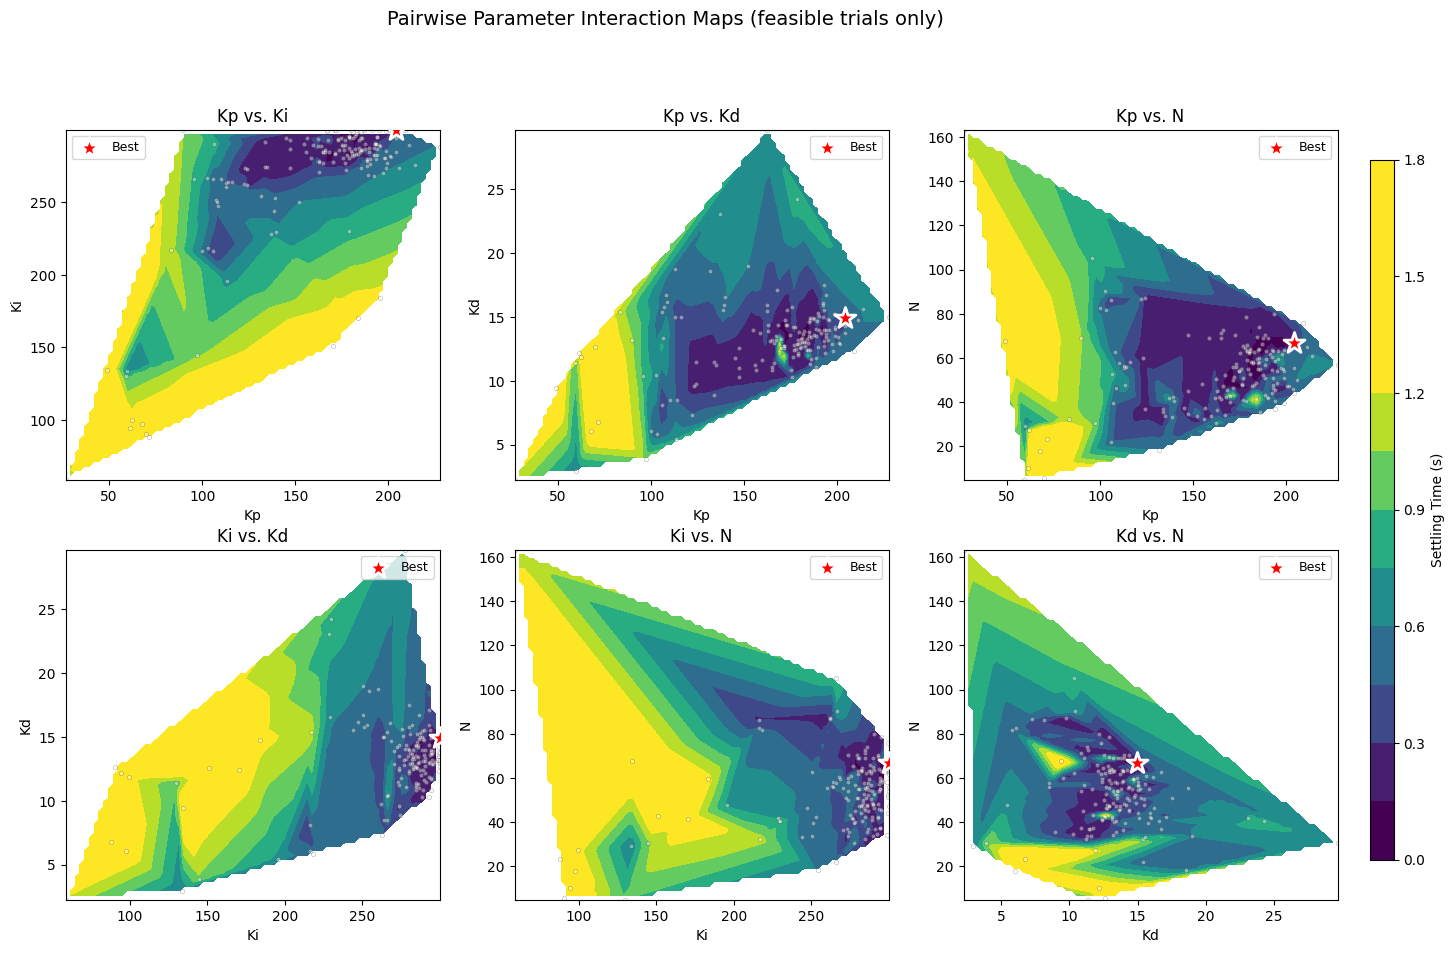

In [ ]:
from scipy.interpolate import griddata

def plot_contour_interaction(df, param_x, param_y, ax, vmin=None, vmax=None):
    """Plot contour of settling time over (param_x, param_y) plane."""
    feas = df[df['feasible']]

    if len(feas) < 10:
        ax.text(0.5, 0.5, 'Not enough feasible points',
                ha='center', va='center', transform=ax.transAxes)
        return

    x = feas[param_x].values
    y = feas[param_y].values
    z = feas['settling_time'].values

    # Interpolate onto a regular grid
    xi = np.linspace(x.min(), x.max(), 80)
    yi = np.linspace(y.min(), y.max(), 80)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi = griddata((x, y), z, (Xi, Yi), method='linear')

    contour = ax.contourf(Xi, Yi, Zi, levels=15, cmap='viridis',
                          vmin=vmin, vmax=vmax)
    ax.scatter(x, y, c='white', s=10, alpha=0.4, edgecolors='black',
               linewidths=0.3)

    # Highlight best
    best_idx = feas['settling_time'].idxmin()
    ax.scatter(feas.loc[best_idx, param_x], feas.loc[best_idx, param_y],
               c='red', s=250, marker='*', edgecolors='white', linewidths=2,
               zorder=10, label='Best')

    ax.set_xlabel(param_x)
    ax.set_ylabel(param_y)
    ax.legend(loc='best', fontsize=9)
    return contour


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
pairs = [('Kp', 'Ki'), ('Kp', 'Kd'), ('Kp', 'N'),
         ('Ki', 'Kd'), ('Ki', 'N'),  ('Kd', 'N')]

# Common color scale
feas = df[df['feasible']]
vmin, vmax = feas['settling_time'].quantile([0.05, 0.95]).values

for ax, (px, py) in zip(axes.flatten(), pairs):
    cs = plot_contour_interaction(df, px, py, ax, vmin=vmin, vmax=vmax)
    ax.set_title(f'{px} vs. {py}')

# Single shared colorbar
fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7])
fig.colorbar(cs, cax=cbar_ax, label='Settling Time (s)')

plt.suptitle('Pairwise Parameter Interaction Maps (feasible trials only)',
             fontsize=14, y=1.00)
plt.show()

Local Sensitivity Analysis Around the Optimum

LOCAL SENSITIVITY: ±10% Perturbation Around Optimum

Baseline (BO-optimal):
  Settling time: 0.1251 s
  Overshoot:     1.16 %
  Peak force:    1199.03 N



/tmp/ipykernel_686/2209227432.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  iae = np.trapz(np.abs(error), t)
/tmp/ipykernel_686/2209227432.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ise = np.trapz(error**2, t)
/tmp/ipykernel_686/2209227432.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_effort = np.trapz(np.abs(u), t)


Parameter  Δ (%)  Settling (s)  Δ Settling (%)       Overshoot (%)         Peak F (N)
       Kp    -10      0.147574            18.0                 0.0 1178.6111142476727
       Kp     -5      0.135068             8.0  0.3590649961791925  1188.822038908203
       Kp      5      0.465233           272.0  1.9848963142441667 1209.2438882292636
       Kp     10      0.537769           330.0  2.8098025682153027 1219.4548128897939
       Ki    -10      0.630315           404.0  0.6795319577397763 1199.0329635687333
       Ki     -5      0.527764           322.0   0.921866093985213 1199.0329635687333
       Ki      5      0.125063             0.0  1.4081732912427203 1199.0329635687333
       Ki     10      0.125063             0.0  1.6520509943255046 1199.0329635687333
       Kd    -10      0.220110            76.0  2.7342197061301476 1099.5515165329205
       Kd     -5      0.125063             0.0  1.9222542367935969 1149.2922400508269
       Kd      5      0.127564             2.0 0.45521

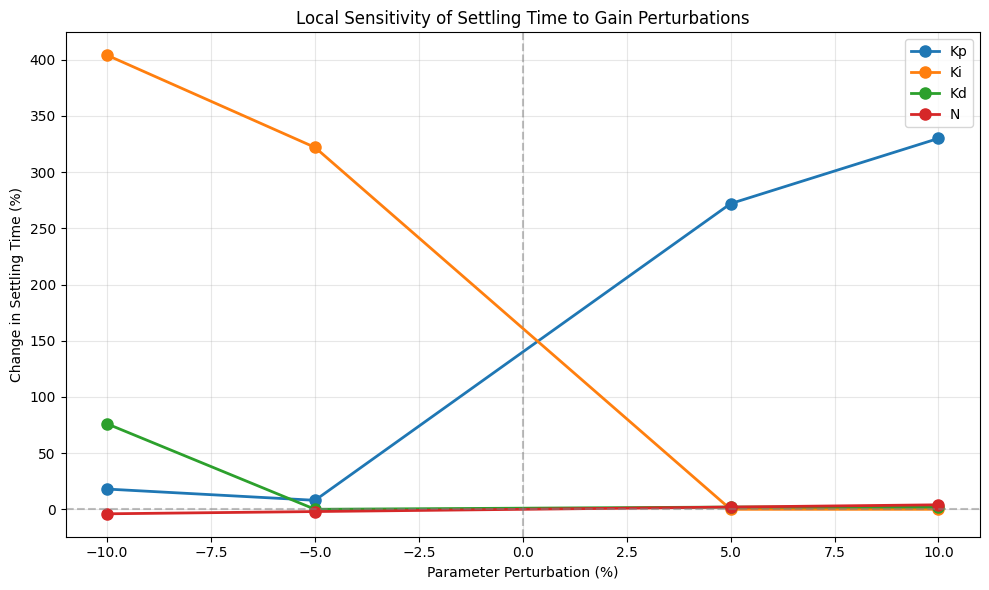

In [ ]:
print("="*60)
print("LOCAL SENSITIVITY: ±10% Perturbation Around Optimum")
print("="*60)

best_gains = best.params.copy()
baseline = evaluate_pid_full(**best_gains, plant=G)
baseline_settling = baseline['settling_time']

print(f"\nBaseline (BO-optimal):")
print(f"  Settling time: {baseline_settling:.4f} s")
print(f"  Overshoot:     {baseline['overshoot']:.2f} %")
print(f"  Peak force:    {baseline['peak_force']:.2f} N")
print()

perturbation_results = []
perturbations = [-0.10, -0.05, 0.05, 0.10]

for param in ['Kp', 'Ki', 'Kd', 'N']:
    for delta in perturbations:
        perturbed = best_gains.copy()
        perturbed[param] = best_gains[param] * (1 + delta)

        res = evaluate_pid_full(**perturbed, plant=G)

        if res.get('is_stable', False):
            perturbation_results.append({
                'Parameter': param,
                'Δ (%)':     int(delta * 100),
                'Settling (s)': res['settling_time'],
                'Δ Settling (%)': (res['settling_time'] / baseline_settling - 1) * 100,
                'Overshoot (%)':  res['overshoot'],
                'Peak F (N)':     res['peak_force'],
            })
        else:
            perturbation_results.append({
                'Parameter': param,
                'Δ (%)': int(delta * 100),
                'Settling (s)': np.nan,
                'Δ Settling (%)': np.nan,
                'Overshoot (%)': np.nan,
                'Peak F (N)': np.nan,
            })

sens_df = pd.DataFrame(perturbation_results)
print(sens_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
for param in ['Kp', 'Ki', 'Kd', 'N']:
    sub = sens_df[sens_df['Parameter'] == param]
    ax.plot(sub['Δ (%)'], sub['Δ Settling (%)'], 'o-', label=param,
            linewidth=2, markersize=8)

ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Parameter Perturbation (%)')
ax.set_ylabel('Change in Settling Time (%)')
ax.set_title('Local Sensitivity of Settling Time to Gain Perturbations')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Summary Findings for the Paper

In [ ]:
print("="*70)
print("SUMMARY OF SENSITIVITY ANALYSIS — FINDINGS FOR PAPER")
print("="*70)

print("\n1. PARAMETER IMPORTANCE (fANOVA):")
for p, v in importance.items():
    print(f"     {p}: {v*100:.1f}% of settling-time variance")

most_important = max(importance, key=importance.get)
least_important = min(importance, key=importance.get)
print(f"\n   → Most influential: {most_important}")
print(f"   → Least influential: {least_important}")

print(f"\n2. FEASIBLE REGION:")
print(f"     Feasible trials: {df['feasible'].sum()} / {len(df)} "
      f"({df['feasible'].mean()*100:.1f}%)")

print(f"\n3. LOCAL SENSITIVITY (max |Δ settling time| under ±10% perturbation):")
max_sens = sens_df.groupby('Parameter')['Δ Settling (%)'].apply(
    lambda x: x.abs().max()
)
for param, val in max_sens.items():
    print(f"     {param}: {val:.2f}%")

print(f"\n4. OPTIMAL GAINS (for reference):")
for p, v in best_gains.items():
    print(f"     {p} = {v:.4f}")

SUMMARY OF SENSITIVITY ANALYSIS — FINDINGS FOR PAPER

1. PARAMETER IMPORTANCE (fANOVA):
     Ki: 80.1% of settling-time variance
     Kp: 17.7% of settling-time variance
     Kd: 1.9% of settling-time variance
     N: 0.3% of settling-time variance

   → Most influential: Ki
   → Least influential: N

2. FEASIBLE REGION:
     Feasible trials: 164 / 300 (54.7%)

3. LOCAL SENSITIVITY (max |Δ settling time| under ±10% perturbation):
     Kd: 76.00%
     Ki: 404.00%
     Kp: 330.00%
     N: 4.00%

4. OPTIMAL GAINS (for reference):
     Kp = 204.2185
     Ki = 299.9179
     Kd = 14.9299
     N = 66.6323


Monte-Carlo

In [ ]:
import pandas as pd
from tqdm import tqdm

# Nominal plant parameters
M_NOM = 1.0
C_NOM = 10.0
K_NOM = 20.0

# Perturbation level
PERTURBATION = 0.20   # ±20% on each parameter
N_SAMPLES = 200       # Monte Carlo samples

# Controllers to test (fixed gains, plant varies)
controllers = {
    'MATLAB': {'Kp': 37.7982, 'Ki': 114.7055, 'Kd': 2.4377,  'N': 475.5737},
    'BO':     {'Kp': 204.2185, 'Ki': 299.9179, 'Kd': 14.9299, 'N': 66.6323},
}

# Engineering specifications
MAX_OVERSHOOT = 5.0
MAX_SSE = 0.01
MAX_PEAK_FORCE = 1200.0


def sample_perturbed_plant(rng, perturbation=PERTURBATION):
    """Sample plant parameters uniformly in [nominal*(1-p), nominal*(1+p)]."""
    m = M_NOM * (1 + rng.uniform(-perturbation, perturbation))
    c = C_NOM * (1 + rng.uniform(-perturbation, perturbation))
    k = K_NOM * (1 + rng.uniform(-perturbation, perturbation))
    return m, c, k


rng = np.random.default_rng(seed=42)
mc_records = []

print(f"Running Monte Carlo: {N_SAMPLES} samples × {len(controllers)} controllers")
print(f"Perturbation: ±{PERTURBATION*100:.0f}% on m, c, k")
print("-" * 60)

for i in tqdm(range(N_SAMPLES)):
    m_s, c_s, k_s = sample_perturbed_plant(rng)
    G_perturbed = tf([1], [m_s, c_s, k_s])

    for ctrl_name, gains in controllers.items():
        res = evaluate_pid_full(**gains, plant=G_perturbed)

        record = {
            'sample': i,
            'controller': ctrl_name,
            'm': m_s, 'c': c_s, 'k': k_s,
            'is_stable': res.get('is_stable', False),
        }

        if res.get('is_stable', False):
            record.update({
                'settling_time': res['settling_time'],
                'overshoot':     res['overshoot'],
                'peak_force':    res['peak_force'],
                'total_effort':  res['total_effort'],
                'iae':           res['iae'],
                'ise':           res['ise'],
                'meets_specs': (
                    res['overshoot']  <= MAX_OVERSHOOT and
                    res['sse']        <= MAX_SSE and
                    res['peak_force'] <= MAX_PEAK_FORCE
                )
            })
        else:
            record.update({k: np.nan for k in
                ['settling_time', 'overshoot', 'peak_force',
                 'total_effort', 'iae', 'ise']})
            record['meets_specs'] = False

        mc_records.append(record)

mc_df = pd.DataFrame(mc_records)
print(f"\nDone. Total simulations: {len(mc_df)}")

Monte Carlo Statistics

In [ ]:
import control

print("="*70)
print("MONTE CARLO ROBUSTNESS — SUMMARY STATISTICS")
print(f"Plant variation: ±{PERTURBATION*100:.0f}% on m, c, k  |  "
      f"Samples: {N_SAMPLES}")
print("="*70)

# Convert NamedSignal objects in performance metrics columns to scalar floats
def extract_scalar_if_named_signal(val):
    if isinstance(val, control.NamedSignal):
        return val.item()
    return val

metrics_to_convert = ['overshoot', 'peak_force', 'total_effort', 'iae', 'ise']

for col in metrics_to_convert:
    if col in mc_df.columns:
        mc_df[col] = mc_df[col].apply(extract_scalar_if_named_signal)

for ctrl in ['MATLAB', 'BO']:
    sub = mc_df[mc_df['controller'] == ctrl]
    stable = sub[sub['is_stable']]

    print(f"\n--- {ctrl} controller ---")
    print(f"  Stable trials: {len(stable)} / {len(sub)} "
          f"({len(stable)/len(sub)*100:.1f}%)")
    print(f"  Meets all specs: {sub['meets_specs'].sum()} / {len(sub)} "
          f"({sub['meets_specs'].mean()*100:.1f}%)")

    if len(stable) == 0:
        continue

    print(f"\n  Settling time (s):")
    print(f"    mean={stable['settling_time'].mean():.4f}, "
          f"std={stable['settling_time'].std():.4f}, "
          f"max={stable['settling_time'].max():.4f}")

    print(f"  Overshoot (%):")
    print(f"    mean={stable['overshoot'].mean():.3f}, "
          f"std={stable['overshoot'].std():.3f}, "
          f"max={stable['overshoot'].max():.3f}")

    print(f"  Peak force (N):")
    print(f"    mean={stable['peak_force'].mean():.2f}, "
          f"std={stable['peak_force'].std():.2f}, "
          f"max={stable['peak_force'].max():.2f}")

    print(f"  IAE: mean={stable['iae'].mean():.4f}, "
          f"std={stable['iae'].std():.4f}")
    print(f"  ISE: mean={stable['ise'].mean():.4f}, "
          f"std={stable['ise'].std():.4f}")

MONTE CARLO ROBUSTNESS — SUMMARY STATISTICS
Plant variation: ±20% on m, c, k  |  Samples: 200

--- MATLAB controller ---
  Stable trials: 200 / 200 (100.0%)
  Meets all specs: True / 200 (0.5%)

  Settling time (s):
    mean=1.1762, std=0.2589, max=1.5633
  Overshoot (%):
    mean=6.967, std=3.041, max=13.148
  Peak force (N):
    mean=1197.10, std=0.00, max=1197.10
  IAE: mean=0.2492, std=0.0282
  ISE: mean=0.1339, std=0.0090

--- BO controller ---
  Stable trials: 200 / 200 (100.0%)
  Meets all specs: True / 200 (0.5%)

  Settling time (s):
    mean=0.4471, std=0.2565, max=0.9255
  Overshoot (%):
    mean=2.170, std=2.261, max=8.233
  Peak force (N):
    mean=1199.03, std=0.00, max=1199.03
  IAE: mean=0.0711, std=0.0081
  ISE: mean=0.0346, std=0.0023


Distribution

/tmp/ipykernel_686/561918171.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_686/561918171.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_686/561918171.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_686/561918171.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/tmp/ipykernel_686/561918171.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() ha

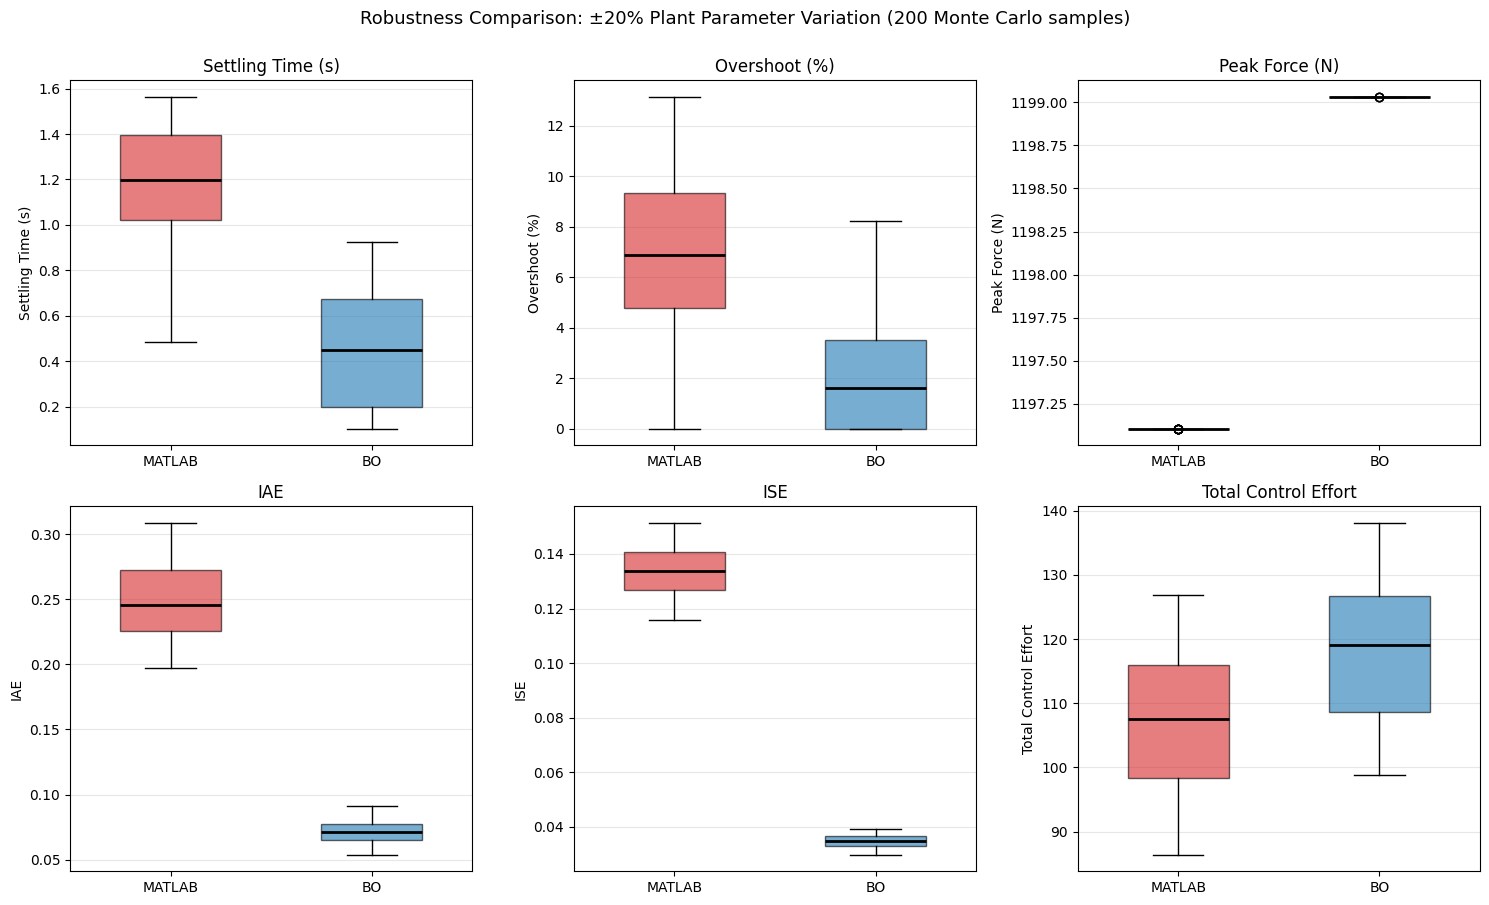

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

metrics_to_plot = [
    ('settling_time', 'Settling Time (s)',  axes[0, 0]),
    ('overshoot',     'Overshoot (%)',      axes[0, 1]),
    ('peak_force',    'Peak Force (N)',     axes[0, 2]),
    ('iae',           'IAE',                axes[1, 0]),
    ('ise',           'ISE',                axes[1, 1]),
    ('total_effort',  'Total Control Effort', axes[1, 2]),
]

palette = {'MATLAB': '#d62728', 'BO': '#1f77b4'}

for metric, label, ax in metrics_to_plot:
    data_matlab = mc_df[(mc_df['controller'] == 'MATLAB') &
                        mc_df['is_stable']][metric].dropna()
    data_bo     = mc_df[(mc_df['controller'] == 'BO') &
                        mc_df['is_stable']][metric].dropna()

    bp = ax.boxplot(
        [data_matlab, data_bo],
        labels=['MATLAB', 'BO'],
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color='black', linewidth=2),
    )
    for patch, ctrl in zip(bp['boxes'], ['MATLAB', 'BO']):
        patch.set_facecolor(palette[ctrl])
        patch.set_alpha(0.6)

    ax.set_ylabel(label)
    ax.set_title(label)
    ax.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'Robustness Comparison: ±{PERTURBATION*100:.0f}% Plant Parameter Variation '
             f'({N_SAMPLES} Monte Carlo samples)', fontsize=13, y=1.00)
plt.tight_layout()
plt.show()

Dominant Spec

SPEC COMPLIANCE BREAKDOWN
            Unstable  OS > 5%  Force > 1200N Meets all
Controller                                            
MATLAB             0      142              0      True
BO                 0       30              0      True


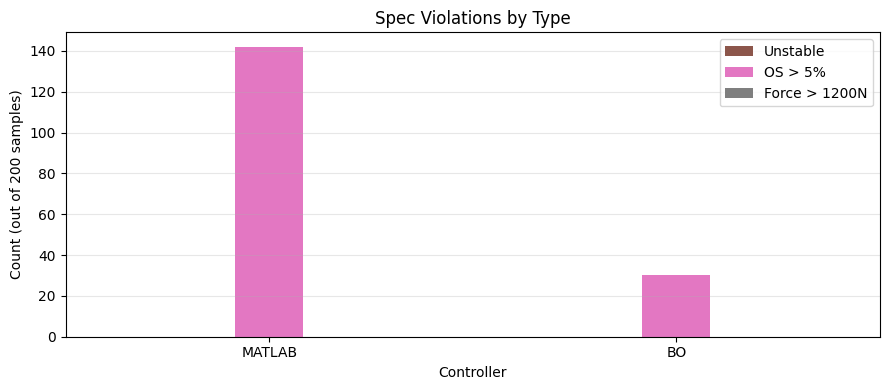

In [ ]:
spec_failures = []
for ctrl in ['MATLAB', 'BO']:
    sub = mc_df[mc_df['controller'] == ctrl]
    stable = sub[sub['is_stable']]

    spec_failures.append({
        'Controller': ctrl,
        'Unstable':       (~sub['is_stable']).sum(),
        'OS > 5%':        (stable['overshoot']  > MAX_OVERSHOOT).sum(),
        'Force > 1200N':  (stable['peak_force'] > MAX_PEAK_FORCE).sum(),
        'Meets all':      sub['meets_specs'].sum(),
    })

failure_df = pd.DataFrame(spec_failures).set_index('Controller')
print("="*60)
print("SPEC COMPLIANCE BREAKDOWN")
print("="*60)
print(failure_df)

fig, ax = plt.subplots(figsize=(9, 4))
failure_df.drop(columns='Meets all').plot(kind='bar', ax=ax,
    color=['#8c564b', '#e377c2', '#7f7f7f'])
ax.set_ylabel('Count (out of {} samples)'.format(N_SAMPLES))
ax.set_title('Spec Violations by Type')
ax.set_xticklabels(failure_df.index, rotation=0)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Sensitivity HeatMap

CORRELATION: Plant Parameter Variation vs. Performance Degradation
Higher |correlation| = controller more sensitive to that parameter



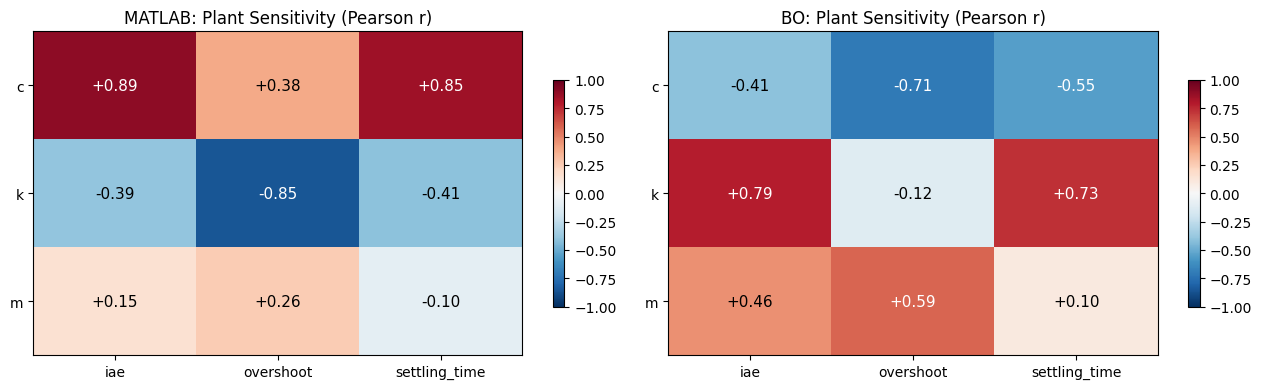

In [ ]:
from scipy.stats import pearsonr

print("="*70)
print("CORRELATION: Plant Parameter Variation vs. Performance Degradation")
print("="*70)
print("Higher |correlation| = controller more sensitive to that parameter\n")

correlations = []
for ctrl in ['MATLAB', 'BO']:
    stable = mc_df[(mc_df['controller'] == ctrl) & mc_df['is_stable']]

    for plant_param in ['m', 'c', 'k']:
        for perf_metric in ['settling_time', 'overshoot', 'iae']:
            r, _ = pearsonr(stable[plant_param], stable[perf_metric])
            correlations.append({
                'Controller': ctrl,
                'Plant Param': plant_param,
                'Performance': perf_metric,
                'Pearson r': r,
            })

corr_df = pd.DataFrame(correlations)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, ctrl in zip(axes, ['MATLAB', 'BO']):
    sub = corr_df[corr_df['Controller'] == ctrl].pivot(
        index='Plant Param', columns='Performance', values='Pearson r'
    )
    im = ax.imshow(sub.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(len(sub.columns)))
    ax.set_xticklabels(sub.columns)
    ax.set_yticks(range(len(sub.index)))
    ax.set_yticklabels(sub.index)
    ax.set_title(f'{ctrl}: Plant Sensitivity (Pearson r)')

    for i in range(len(sub.index)):
        for j in range(len(sub.columns)):
            val = sub.values[i, j]
            ax.text(j, i, f'{val:+.2f}', ha='center', va='center',
                    color='white' if abs(val) > 0.5 else 'black',
                    fontsize=11)

    plt.colorbar(im, ax=ax, shrink=0.7)

plt.tight_layout()
plt.show()

In [ ]:
print("="*70)
print("MONTE CARLO ROBUSTNESS — CORRECTED SUMMARY")
print(f"Plant variation: ±{PERTURBATION*100:.0f}% on m, c, k  |  "
      f"Samples: {N_SAMPLES}")
print("="*70)

for ctrl in ['MATLAB', 'BO']:
    sub = mc_df[mc_df['controller'] == ctrl]
    stable = sub[sub['is_stable']]
    meets = sub['meets_specs'].sum()   # this is the actual count

    print(f"\n--- {ctrl} controller ---")
    print(f"  Stable: {len(stable)}/{len(sub)} ({len(stable)/len(sub)*100:.1f}%)")
    print(f"  Meets ALL specs: {meets}/{len(sub)} ({meets/len(sub)*100:.1f}%)")

    # Per-spec compliance
    os_ok    = (stable['overshoot']  <= MAX_OVERSHOOT).sum()
    force_ok = (stable['peak_force'] <= MAX_PEAK_FORCE).sum()

    print(f"  Per-spec compliance (out of stable trials):")
    print(f"    OS ≤ 5%:       {os_ok}/{len(stable)} ({os_ok/len(stable)*100:.1f}%)")
    print(f"    |F| ≤ 1200N:   {force_ok}/{len(stable)} ({force_ok/len(stable)*100:.1f}%)")

    print(f"\n  Settling time: mean={stable['settling_time'].mean():.4f}, "
          f"std={stable['settling_time'].std():.4f}, "
          f"max={stable['settling_time'].max():.4f}")
    print(f"  Overshoot:     mean={stable['overshoot'].mean():.3f}, "
          f"std={stable['overshoot'].std():.3f}, "
          f"max={stable['overshoot'].max():.3f}")
    print(f"  IAE:           mean={stable['iae'].mean():.4f}, "
          f"std={stable['iae'].std():.4f}")
    print(f"  ISE:           mean={stable['ise'].mean():.4f}, "
          f"std={stable['ise'].std():.4f}")

MONTE CARLO ROBUSTNESS — CORRECTED SUMMARY
Plant variation: ±20% on m, c, k  |  Samples: 200

--- MATLAB controller ---
  Stable: 200/200 (100.0%)
  Meets ALL specs: True/200 (0.5%)
  Per-spec compliance (out of stable trials):
    OS ≤ 5%:       58/200 (29.0%)
    |F| ≤ 1200N:   200/200 (100.0%)

  Settling time: mean=1.1762, std=0.2589, max=1.5633
  Overshoot:     mean=6.967, std=3.041, max=13.148
  IAE:           mean=0.2492, std=0.0282
  ISE:           mean=0.1339, std=0.0090

--- BO controller ---
  Stable: 200/200 (100.0%)
  Meets ALL specs: True/200 (0.5%)
  Per-spec compliance (out of stable trials):
    OS ≤ 5%:       170/200 (85.0%)
    |F| ≤ 1200N:   200/200 (100.0%)

  Settling time: mean=0.4471, std=0.2565, max=0.9255
  Overshoot:     mean=2.170, std=2.261, max=8.233
  IAE:           mean=0.0711, std=0.0081
  ISE:           mean=0.0346, std=0.0023


Stratified Analysis

In [ ]:
# Multiple perturbation levels
PERTURBATION_LEVELS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
N_SAMPLES_PER_LEVEL = 100

stratified_records = []

for p_level in PERTURBATION_LEVELS:
    rng_strat = np.random.default_rng(seed=int(p_level * 1000))

    print(f"Perturbation level: ±{p_level*100:.0f}%", end=' ')

    for i in range(N_SAMPLES_PER_LEVEL):
        m_s = M_NOM * (1 + rng_strat.uniform(-p_level, p_level))
        c_s = C_NOM * (1 + rng_strat.uniform(-p_level, p_level))
        k_s = K_NOM * (1 + rng_strat.uniform(-p_level, p_level))
        G_p = tf([1], [m_s, c_s, k_s])

        for ctrl_name, gains in controllers.items():
            res = evaluate_pid_full(**gains, plant=G_p)

            rec = {
                'perturbation': p_level,
                'sample': i,
                'controller': ctrl_name,
                'is_stable': res.get('is_stable', False),
            }

            if res.get('is_stable', False):
                rec.update({
                    'settling_time': res['settling_time'],
                    'overshoot':     res['overshoot'],
                    'peak_force':    res['peak_force'],
                    'iae':           res['iae'],
                    'ise':           res['ise'],
                    'os_compliant':    res['overshoot']  <= MAX_OVERSHOOT,
                    'force_compliant': res['peak_force'] <= MAX_PEAK_FORCE,
                    'sse_compliant':   res['sse']        <= MAX_SSE,
                })
                rec['meets_specs'] = (rec['os_compliant'] and
                                       rec['force_compliant'] and
                                       rec['sse_compliant'])
            else:
                for k_ in ['settling_time', 'overshoot', 'peak_force',
                           'iae', 'ise']:
                    rec[k_] = np.nan
                rec['os_compliant'] = False
                rec['force_compliant'] = False
                rec['sse_compliant'] = False
                rec['meets_specs'] = False

            stratified_records.append(rec)
    print("done.")

strat_df = pd.DataFrame(stratified_records)
print(f"\nTotal simulations: {len(strat_df)}")

Compliance Rate vs. Perturbation Level

In [ ]:
print("="*70)
print("COMPLIANCE RATE vs. PERTURBATION LEVEL")
print("="*70)

compliance_table = strat_df.groupby(['perturbation', 'controller']).agg(
    overall   = ('meets_specs',    'mean'),
    overshoot = ('os_compliant',   'mean'),
    force     = ('force_compliant','mean'),
).reset_index()

# Convert to percentages
for col in ['overall', 'overshoot', 'force']:
    compliance_table[col] = compliance_table[col] * 100

print(compliance_table.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'MATLAB': '#d62728', 'BO': '#1f77b4'}

# Overall compliance
for ctrl in ['MATLAB', 'BO']:
    sub = compliance_table[compliance_table['controller'] == ctrl]
    axes[0].plot(sub['perturbation']*100, sub['overall'],
                 'o-', linewidth=2.5, markersize=10,
                 color=palette[ctrl], label=ctrl)

axes[0].set_xlabel('Plant Perturbation (±%)')
axes[0].set_ylabel('Spec Compliance Rate (%)')
axes[0].set_title('Overall Compliance vs. Perturbation Magnitude')
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=11)
axes[0].axhline(y=95, color='gray', linestyle=':', alpha=0.5,
                label='95% target')

# Overshoot-specific compliance
for ctrl in ['MATLAB', 'BO']:
    sub = compliance_table[compliance_table['controller'] == ctrl]
    axes[1].plot(sub['perturbation']*100, sub['overshoot'],
                 'o-', linewidth=2.5, markersize=10,
                 color=palette[ctrl], label=ctrl)

axes[1].set_xlabel('Plant Perturbation (±%)')
axes[1].set_ylabel('Overshoot Spec Compliance (%)')
axes[1].set_title('Overshoot Constraint Compliance')
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

Performance Degradation Curves

In [ ]:
import control

# Helper function (if not already defined in current kernel session)
def extract_scalar_if_named_signal(val):
    if isinstance(val, control.NamedSignal):
        return val.item()
    return val

# Apply conversion to relevant columns in strat_df
metrics_to_convert_strat = ['overshoot', 'peak_force', 'total_effort', 'iae', 'ise']

for col in metrics_to_convert_strat:
    if col in strat_df.columns:
        strat_df[col] = strat_df[col].apply(extract_scalar_if_named_signal)


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = [
    ('settling_time', 'Settling Time (s)', axes[0]),
    ('overshoot',     'Overshoot (%)',     axes[1]),
    ('iae',           'IAE',               axes[2]),
]

for metric, label, ax in metrics_to_plot:
    for ctrl in ['MATLAB', 'BO']:
        sub = strat_df[(strat_df['controller'] == ctrl) & strat_df['is_stable']]
        stats = sub.groupby('perturbation')[metric].agg(['mean', 'std']).reset_index()

        x = stats['perturbation'] * 100
        ax.plot(x, stats['mean'], 'o-', linewidth=2.5, markersize=10,
                color=palette[ctrl], label=ctrl)
        ax.fill_between(x,
                        stats['mean'] - stats['std'],
                        stats['mean'] + stats['std'],
                        alpha=0.2, color=palette[ctrl])

    ax.set_xlabel('Plant Perturbation (±%)')
    ax.set_ylabel(label)
    ax.set_title(f'{label} (mean ± std)')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

plt.suptitle('Performance Degradation Under Increasing Plant Uncertainty',
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CORRECTED STRATIFIED MONTE CARLO ROBUSTNESS
# ============================================================
PERTURBATION_LEVELS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
N_SAMPLES_PER_LEVEL = 100

# Use the MSD plant and the two MSD controllers
M_NOM, C_NOM, K_NOM = 1.0, 10.0, 20.0
controllers = {
    'MATLAB': {'Kp': 37.7982,  'Ki': 114.7055, 'Kd': 2.4377,  'N': 475.5737},
    'BO':     {'Kp': 204.2185, 'Ki': 299.9179, 'Kd': 14.9299, 'N': 66.6323},
}

MAX_OVERSHOOT  = 5.0
MAX_SSE        = 0.01
MAX_PEAK_FORCE = 1200.0

stratified_records = []

for p_level in PERTURBATION_LEVELS:
    rng = np.random.default_rng(seed=int(p_level * 10000))

    for i in range(N_SAMPLES_PER_LEVEL):
        m_s = M_NOM * (1 + rng.uniform(-p_level, p_level))
        c_s = C_NOM * (1 + rng.uniform(-p_level, p_level))
        k_s = K_NOM * (1 + rng.uniform(-p_level, p_level))
        G_perturbed = tf([1], [m_s, c_s, k_s])

        for ctrl_name, gains in controllers.items():
            res = evaluate_pid_full(**gains, plant=G_perturbed)

            if res.get('is_stable', False):
                os_ok    = bool(res['overshoot']  <= MAX_OVERSHOOT)
                force_ok = bool(res['peak_force'] <= MAX_PEAK_FORCE)
                sse_ok   = bool(res['sse']        <= MAX_SSE)
                meets    = os_ok and force_ok and sse_ok
            else:
                os_ok = force_ok = sse_ok = meets = False

            stratified_records.append({
                'perturbation': p_level,
                'controller':   ctrl_name,
                'os_ok':        os_ok,
                'force_ok':     force_ok,
                'sse_ok':       sse_ok,
                'meets_specs':  meets,
                'overshoot':    res.get('overshoot', np.nan),
            })

strat_df = pd.DataFrame(stratified_records)

# Compute compliance rates as percentages
compliance = strat_df.groupby(['perturbation', 'controller']).agg(
    overall_pct   = ('meets_specs', lambda x: 100 * x.mean()),
    overshoot_pct = ('os_ok',       lambda x: 100 * x.mean()),
    force_pct     = ('force_ok',    lambda x: 100 * x.mean()),
    mean_os       = ('overshoot',   'mean'),
    max_os        = ('overshoot',   'max'),
).reset_index()

print("="*80)
print("STRATIFIED COMPLIANCE RATES (% of samples meeting each constraint)")
print("="*80)
print(compliance.to_string(index=False))

print("\n" + "="*80)
print("DIAGNOSTIC: Mean and max overshoot at each perturbation level")
print("="*80)
print("If MATLAB's mean OS exceeds 5%, its overshoot compliance should be low.")
print("If both controllers show identical 100% compliance, something is wrong.")

/tmp/ipykernel_686/2209227432.py:69: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  iae = np.trapz(np.abs(error), t)
/tmp/ipykernel_686/2209227432.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ise = np.trapz(error**2, t)
/tmp/ipykernel_686/2209227432.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_effort = np.trapz(np.abs(u), t)


STRATIFIED COMPLIANCE RATES (% of samples meeting each constraint)
 perturbation controller  overall_pct  overshoot_pct  force_pct            mean_os             max_os
         0.05         BO        100.0          100.0      100.0 1.0400186723656006   2.85740127746148
         0.05     MATLAB          1.0            1.0      100.0  6.584920803069767  8.364667447485274
         0.10         BO        100.0          100.0      100.0 1.2256655278332744  4.348204816964296
         0.10     MATLAB         14.0           14.0      100.0  6.723812851614088  9.690234364628324
         0.15         BO         95.0           95.0      100.0 1.6940863202969865  6.578738524073469
         0.15     MATLAB         21.0           21.0      100.0   7.09865532222744 11.808481102411417
         0.20         BO         94.0           94.0      100.0  1.572232185990847  8.252309325333185
         0.20     MATLAB         22.0           22.0      100.0  7.255367777807141  13.63436211104787
         0.25  